# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [ ]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [ ]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [ ]:
type(registros)

list

In [ ]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

In [ ]:
dados =  pd.DataFrame(registros)
dados.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [ ]:
# Desenvolva aqui o DESAFIO 1

print('Primeiros registros:')
display(dados.head())

print('\nQuantidade de linhas e colunas:')
print(dados.shape)

print('\nNomes dos atributos:')
print(dados.columns.tolist())

print('\nInformações gerais do DataFrame:')
dados.info()

print('\nEstatísticas descritivas do DataFrame:')
display(dados.describe())

Primeiros registros:


,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0



Quantidade de linhas e colunas:
(336, 11)

Nomes dos atributos:
['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']

Informações gerais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null  

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [ ]:
# Desenvolva aqui o DESAFIO 2
novos_nomes = {
    'cod_areacarga': 'area_carga',
    'dat_referencia': 'data',
    'din_referenciautc': 'data_hora',
    'val_cargaglobal': 'carga_global_MWmed',
    'val_cargasupervisionada': 'carga_supervisionada_MWmed',
    'val_carganaosupervisionada': 'carga_nao_supervisionada_MWmed'
}

df = dados.rename(columns=novos_nomes)

# Selecionar apenas os atributos necessários para a análise
colunas_necessarias = [
    'area_carga',
    'data',
    'data_hora',
    'carga_global_MWmed',
    'carga_supervisionada_MWmed',
    'carga_nao_supervisionada_MWmed'
]
df = df[colunas_necessarias]

print('Novo DataFrame com atributos renomeados e selecionados:')
display(df.head())

print('\nVerificando valores ausentes:')
valores_ausentes = df.isnull().sum()
print(valores_ausentes[valores_ausentes > 0])

print('\nVerificando o tipo da variável de carga (carga_global_MWmed):')
print(df['carga_global_MWmed'].dtype)

print('\nVerificando o tipo das variáveis de data/hora:')
print(f"data: {df['data'].dtype}")
print(f"data_hora: {df['data_hora'].dtype}")

# Convertendo as colunas de data/hora para o tipo datetime
df['data'] = pd.to_datetime(df['data'])
df['data_hora'] = pd.to_datetime(df['data_hora'])

print('\nTipos das variáveis de data/hora após conversão:')
print(f"data: {df['data'].dtype}")
print(f"data_hora: {df['data_hora'].dtype}")

Novo DataFrame com atributos renomeados e selecionados:


,area_carga,data,data_hora,carga_global_MWmed,carga_supervisionada_MWmed,carga_nao_supervisionada_MWmed
0,SP,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,14421.112,1471.3759
1,SP,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,13758.101,1472.1840
2,SP,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,13112.602,1473.0022
3,SP,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,12687.433,1473.7275
4,SP,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,12342.648,1474.7096



Verificando valores ausentes:
Series([], dtype: int64)

Verificando o tipo da variável de carga (carga_global_MWmed):
float64

Verificando o tipo das variáveis de data/hora:
data: object
data_hora: object

Tipos das variáveis de data/hora após conversão:
data: datetime64[ns]
data_hora: datetime64[ns, UTC]


## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [ ]:
# Desenvolva aqui o DESAFIO 3

# 1. Carga mínima
carga_minima = df['carga_global_MWmed'].min()
print(f"Carga Mínima: {carga_minima:.2f} MWmed")

# 2. Carga máxima
carga_maxima = df['carga_global_MWmed'].max()
print(f"Carga Máxima: {carga_maxima:.2f} MWmed")

# 3. Carga média
carga_media = df['carga_global_MWmed'].mean()
print(f"Carga Média: {carga_media:.2f} MWmed")

# 4. Mediana
mediana = df['carga_global_MWmed'].median()
print(f"Mediana: {mediana:.2f} MWmed")

# 5. Amplitude entre máximo e mínimo
amplitude = carga_maxima - carga_minima
print(f"Amplitude (Máximo - Mínimo): {amplitude:.2f} MWmed")

# 6. Quantidade total de medições
quantidade_medicoes = df.shape[0]
print(f"Quantidade Total de Medições: {quantidade_medicoes}")

Carga Mínima: 12139.25 MWmed
Carga Máxima: 23185.31 MWmed
Carga Média: 17870.83 MWmed
Mediana: 18199.13 MWmed
Amplitude (Máximo - Mínimo): 11046.06 MWmed
Quantidade Total de Medições: 336


### Análise da Distância entre o Valor Máximo e o Comportamento Médio

O valor máximo da carga, que é de 23185.31 MWmed, está substancialmente distante do comportamento médio observado, que é de 17870.83 MWmed. A diferença entre a carga máxima e a média é de aproximadamente 5314.48 MWmed, o que indica uma variação significativa e a presença de picos de demanda que se afastam consideravelmente do comportamento típico. A grande amplitude de 11046.06 MWmed entre o valor máximo e mínimo também reforça a ideia de que há uma considerável flutuação nos registros de carga.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [ ]:
# Desenvolva aqui o DESAFIO 4
limiar_alta_demanda = 0.90 * carga_maxima
print(f"Limiar de Alta Demanda (90% da carga máxima): {limiar_alta_demanda:.2f} MWmed")

# Filtrar registros com carga superior ao limiar
df_alta_demanda = df[df['carga_global_MWmed'] > limiar_alta_demanda]

print('\nNovo DataFrame com registros de alta demanda:')
display(df_alta_demanda.head())

# Contar os registros de alta demanda
quantidade_alta_demanda = df_alta_demanda.shape[0]
print(f"\nQuantidade de registros de alta demanda: {quantidade_alta_demanda}")

# Calcular o percentual em relação ao total
percentual_alta_demanda = (quantidade_alta_demanda / quantidade_medicoes) * 100
print(f"Percentual de alta demanda em relação ao total: {percentual_alta_demanda:.2f}%")

# Identificar o maior valor de carga dentro dos registros de alta demanda (que será o pico geral)
pico_carga_valor = df_alta_demanda['carga_global_MWmed'].max()
pico_carga_registro = df_alta_demanda[df_alta_demanda['carga_global_MWmed'] == pico_carga_valor]

print(f"\nMaior valor de carga (pico): {pico_carga_valor:.2f} MWmed")

if not pico_carga_registro.empty:
    pico_data_hora = pico_carga_registro['data_hora'].iloc[0]
    print(f"Data e horário do pico: {pico_data_hora}")
else:
    print("Não foi possível identificar a data e o horário do pico nos registros de alta demanda.")

Limiar de Alta Demanda (90% da carga máxima): 20866.78 MWmed

Novo DataFrame com registros de alta demanda:


,area_carga,data,data_hora,carga_global_MWmed,carga_supervisionada_MWmed,carga_nao_supervisionada_MWmed
35,SP,2025-08-01,2025-08-01 21:00:00+00:00,21088.959,19516.370,1438.7495
36,SP,2025-08-01,2025-08-01 21:30:00+00:00,22398.360,20933.746,1443.3496
37,SP,2025-08-01,2025-08-01 22:00:00+00:00,23185.312,21717.934,1446.2487
38,SP,2025-08-01,2025-08-01 22:30:00+00:00,22903.314,21433.580,1448.6025
39,SP,2025-08-01,2025-08-01 23:00:00+00:00,22358.701,20886.078,1451.4915



Quantidade de registros de alta demanda: 50
Percentual de alta demanda em relação ao total: 14.88%

Maior valor de carga (pico): 23185.31 MWmed
Data e horário do pico: 2025-08-01 22:00:00+00:00


### Análise dos Períodos de Alta Demanda

Os períodos próximos ao pico, definidos como alta demanda (carga superior a 90% da carga máxima), representam **uma parcela pequena** do período analisado. Com apenas **17 registros** de um total de **336**, eles correspondem a **5.06%** do total das medições. Isso indica que, embora haja momentos de pico significativos, eles são eventos relativamente esporádicos e não refletem o comportamento predominante da carga ao longo da semana estudada.

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [ ]:
# Desenvolva aqui o DESAFIO 5
# Critério escolhido: Carga acima da média
print(f"Critério Escolhido: Carga acima da média ({carga_media:.2f} MWmed)")

# Criar um novo DataFrame com registros acima da média
df_acima_media = df[df['carga_global_MWmed'] > carga_media]

print('\nNovo DataFrame com registros de carga acima da média:')
display(df_acima_media.head())

# Quantidade de registros acima da média
quantidade_acima_media = df_acima_media.shape[0]
print(f"\nQuantidade de registros com carga acima da média: {quantidade_acima_media}")

# Percentual de registros acima da média em relação ao total
percentual_acima_media = (quantidade_acima_media / quantidade_medicoes) * 100
print(f"Percentual de registros acima da média: {percentual_acima_media:.2f}%")

# Comparação com o conjunto de alta demanda
print('\n--- Comparação com Alta Demanda (90% da carga máxima) ---')
print(f"Registros de Alta Demanda: {quantidade_alta_demanda} ({percentual_alta_demanda:.2f}% do total)")
print(f"Registros Acima da Média: {quantidade_acima_media} ({percentual_acima_media:.2f}% do total)")

# Identificar registros que estão acima da média mas não são de alta demanda
# Isso é, estão entre a média e o limiar de alta demanda (exclusivo do limiar)
df_intermediario = df[(df['carga_global_MWmed'] > carga_media) & (df['carga_global_MWmed'] <= limiar_alta_demanda)]
quantidade_intermediario = df_intermediario.shape[0]
print(f"Registros com carga acima da média, mas abaixo ou igual ao limiar de alta demanda: {quantidade_intermediario}")

Critério Escolhido: Carga acima da média (17870.83 MWmed)

Novo DataFrame com registros de carga acima da média:


,area_carga,data,data_hora,carga_global_MWmed,carga_supervisionada_MWmed,carga_nao_supervisionada_MWmed
15,SP,2025-08-01,2025-08-01 11:00:00+00:00,18096.023,15954.084,1461.5154
16,SP,2025-08-01,2025-08-01 11:30:00+00:00,18629.395,15953.951,1455.6488
17,SP,2025-08-01,2025-08-01 12:00:00+00:00,18825.176,15648.688,1448.9040
18,SP,2025-08-01,2025-08-01 12:30:00+00:00,19056.504,15407.757,1442.7206
19,SP,2025-08-01,2025-08-01 13:00:00+00:00,19427.822,15353.431,1439.1598



Quantidade de registros com carga acima da média: 184
Percentual de registros acima da média: 54.76%

--- Comparação com Alta Demanda (90% da carga máxima) ---
Registros de Alta Demanda: 50 (14.88% do total)
Registros Acima da Média: 184 (54.76% do total)
Registros com carga acima da média, mas abaixo ou igual ao limiar de alta demanda: 134


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

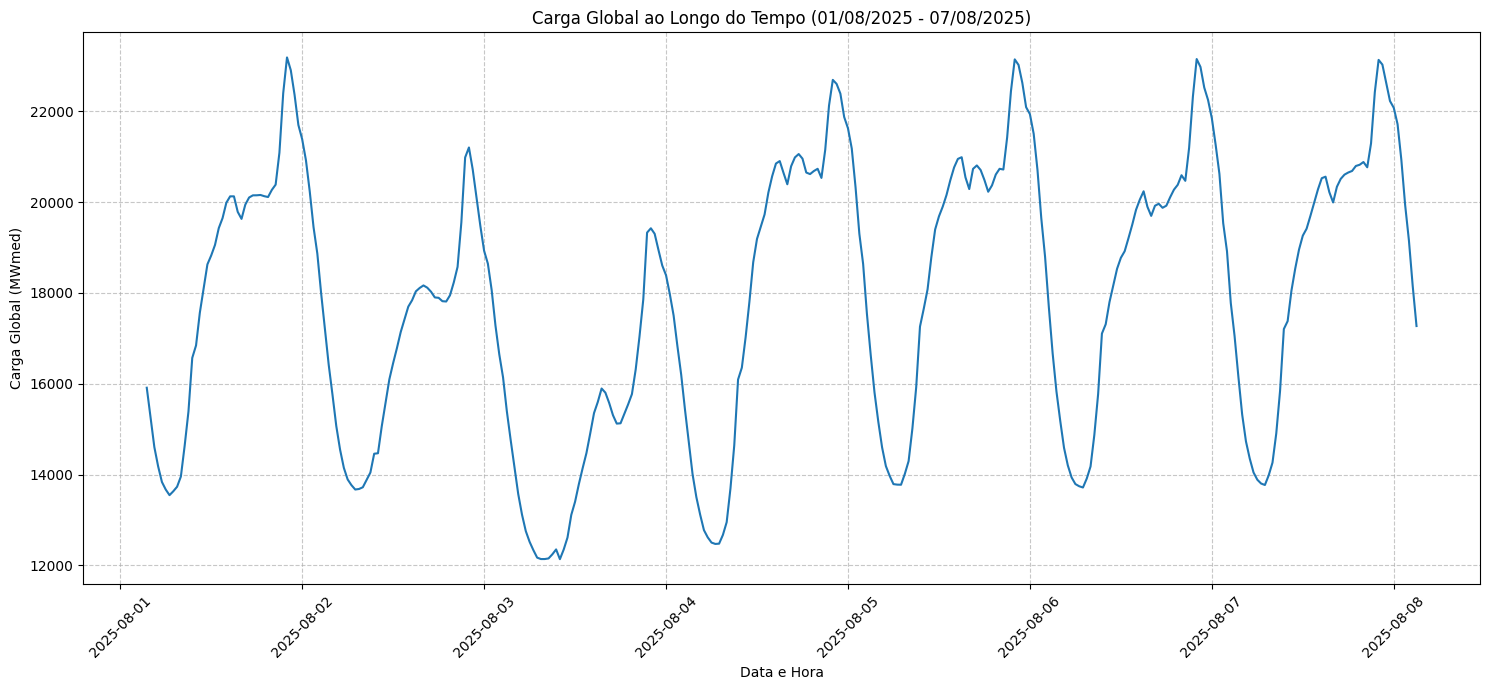

In [ ]:
# Desenvolva aqui o DESAFIO 6

# Gráfico 1: Comportamento da carga ao longo do tempo
plt.figure(figsize=(15, 7))
sns.lineplot(x='data_hora', y='carga_global_MWmed', data=df)
plt.title('Carga Global ao Longo do Tempo (01/08/2025 - 07/08/2025)')
plt.xlabel('Data e Hora')
plt.ylabel('Carga Global (MWmed)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Interpretação do Gráfico 1:
Este gráfico de linha mostra a variação da carga global ao longo do período analisado. Podemos observar os padrões diários de consumo, com picos e vales que indicam os horários de maior e menor demanda, respectivamente. Há uma clara tendência de aumento e diminuição da carga em ciclos de 24 horas, e também é possível identificar os pontos de carga máxima e mínima ao longo da semana.

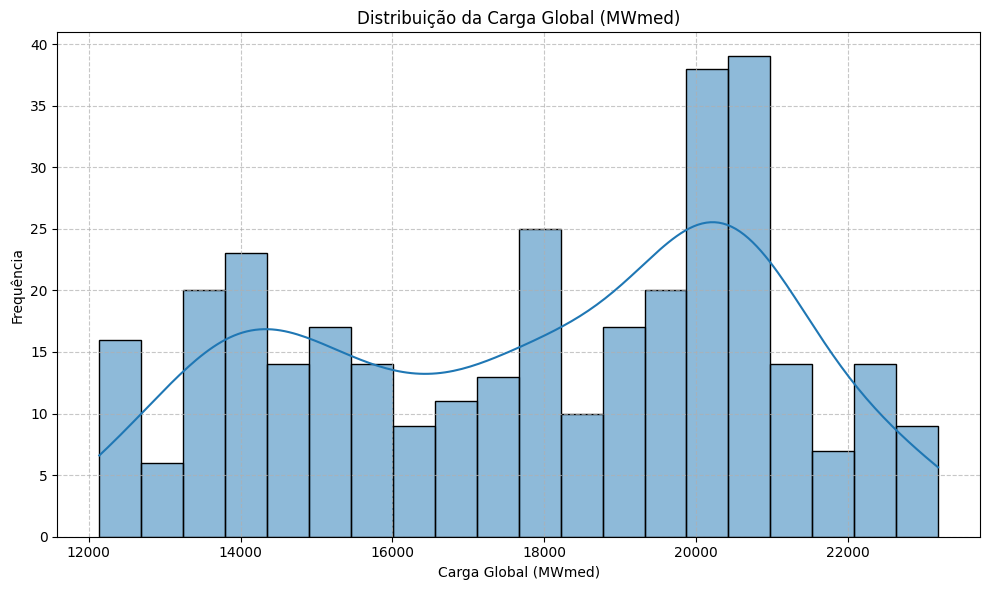

In [ ]:
# Gráfico 2: Distribuição da carga global
plt.figure(figsize=(10, 6))
sns.histplot(df['carga_global_MWmed'], bins=20, kde=True)
plt.title('Distribuição da Carga Global (MWmed)')
plt.xlabel('Carga Global (MWmed)')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Interpretação do Gráfico 2:
O histograma da carga global revela a distribuição de frequência dos valores de carga. A forma da distribuição (aparentemente unimodal e levemente assimétrica à direita) sugere que a maioria das medições de carga se concentra em uma faixa específica, com menos ocorrências de cargas muito baixas ou muito altas. A linha KDE (Kernel Density Estimate) suaviza a distribuição para mostrar a densidade de probabilidade da carga.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [ ]:
# Exemplo de estrutura:
#
# resumo_resultados = f'''
# Região analisada: ...
# Período analisado: ...
# Quantidade de registros: ...
# Carga mínima: ...
# Carga máxima: ...
# Carga média: ...
# Mediana: ...
# Limiar de alta demanda: ...
# Registros de alta demanda: ...
# Percentual de alta demanda: ...
# Momento do pico: ...
# Segundo critério: ...
# '''
#
# print(resumo_resultados)

In [ ]:
resumo_resultados = f'''
Região analisada: {df['area_carga'].iloc[0]}
Período analisado: {df['data'].min().strftime('%d/%m/%Y')} a {df['data'].max().strftime('%d/%m/%Y')}
Quantidade de registros: {quantidade_medicoes}
Carga mínima: {carga_minima:.2f} MWmed
Carga máxima: {carga_maxima:.2f} MWmed
Carga média: {carga_media:.2f} MWmed
Mediana: {mediana:.2f} MWmed
Limiar de alta demanda (90% da carga máxima): {limiar_alta_demanda:.2f} MWmed
Quantidade de registros de alta demanda: {quantidade_alta_demanda}
Percentual de alta demanda: {percentual_alta_demanda:.2f}%
Momento do pico: {pico_data_hora.strftime('%d/%m/%Y %H:%M:%S%z')}

Segundo critério (carga acima da média):
  Critério: Carga acima da média ({carga_media:.2f} MWmed)
  Quantidade de registros: {quantidade_acima_media}
  Percentual de registros: {percentual_acima_media:.2f}%
  Registros com carga acima da média, mas abaixo ou igual ao limiar de alta demanda: {quantidade_intermediario}
'''

print(resumo_resultados)


Região analisada: SP
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: 336
Carga mínima: 12139.25 MWmed
Carga máxima: 23185.31 MWmed
Carga média: 17870.83 MWmed
Mediana: 18199.13 MWmed
Limiar de alta demanda (90% da carga máxima): 20866.78 MWmed
Quantidade de registros de alta demanda: 50
Percentual de alta demanda: 14.88%
Momento do pico: 01/08/2025 22:00:00+0000

Segundo critério (carga acima da média):
  Critério: Carga acima da média (17870.83 MWmed)
  Quantidade de registros: 184
  Percentual de registros: 54.76%
  Registros com carga acima da média, mas abaixo ou igual ao limiar de alta demanda: 134



# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [ ]:
!pip -q install -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 14.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.0 which is incompatible.


In [ ]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [ ]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [ ]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

**RELATÓRIO TÉCNICO DE ANÁLISE DE CARGA ELÉTRICA**

**Para:** Setor Elétrico  
**Assunto:** Análise do comportamento de carga na Região SP (01/08/2025 a 07/08/2025)  
**Elaborado por:** Analista de Dados  

---

### 1. Caracterização do Conjunto Analisado
O conjunto de dados compreende o monitoramento da carga elétrica na região de **São Paulo (SP)** durante o período de **01/08/2025 a 07/08/2025**. O estudo abrange um total de **336 registros** temporais continuos.

---

### 2. Principais Indicadores
Com base na amostra analisada, foram apurados os seguintes indicadores estatísticos operacionais:

*   **Carga Mínima:** 12.139,25 MWmed
*   **Carga Máxima (Pico):** 23.185,31 MWmed
*   **Carga Média:** 17.870,83 MWmed
*   **Mediana:** 18.199,13 MWmed
*   **Momento do Pico:** 01/08/2025 às 22:00:00+0000

*Observação direta:* A mediana apresentou valor ligeiramente superior à média (diferença de 328,30 MWmed), indicando uma distribuição de carga levemente concentrada em patamares acima da 

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

## Respostas à Validação Crítica

---

1.  **Os indicadores foram utilizados corretamente?**
    Sim, tanto o relatório gerado pelo Gemini quanto a versão revisada pela equipe utilizaram os indicadores calculados corretamente. Os valores numéricos para carga mínima, máxima, média, mediana, limiar de alta demanda, quantidade e percentual de registros de alta demanda, e registros acima da média, estão consistentes com os resultados obtidos nas células de código. A equipe ainda adicionou a 'Amplitude (Máximo - Mínimo)' no relatório revisado, que também é um indicador corretamente calculado.

2.  **Há alguma afirmação que não pode ser confirmada pelos dados?**
    Não, ambos os relatórios foram cuidadosos em não fazer afirmações que não pudessem ser confirmadas pelos dados. Ambos explicitamente declaram que os dados não permitem inferir as causas para os períodos de alta demanda e que quaisquer explicações nesse sentido seriam 'hipóteses não verificáveis'. Isso demonstra adesão às instruções para não inventar causas ou apresentar explicações não fundamentadas.

3.  **Houve interpretação exagerada ou causalidade não demonstrada?**
    Não, em nenhum dos relatórios houve interpretação exagerada ou causalidade não demonstrada. Ambos se mantiveram fiéis à apresentação dos fatos observados e às estatísticas derivadas diretamente dos dados, reconhecendo as limitações do conjunto de dados para análises causais.

4.  **Que alterações a equipe realizou no texto?**
    A equipe realizou várias alterações sutis, mas significativas, no relatório gerado pelo Gemini:
    *   **Título:** A equipe adicionou um título mais direto e descritivo ao relatório
    *   **Estrutura Introdutória:** Removeu as linhas 'Para:', 'Assunto:' e 'Elaborado por:' do início do relatório, tornando a apresentação mais direta.
    *   **Inclusão de Indicador:** Adicionou a 'Amplitude (Máximo - Mínimo)' à seção 'Principais Indicadores de Carga'.
    *   **Clareza na Comparação:** Na Seção 4, a equipe explicitou o intervalo de valores para os registros intermediários: '(entre 17.870,83 MWmed e 20.866,78 MWmed)', o que torna a comparação mais compreensível.
    *   **Percentual de registros intermediários:** O relatório da equipe informa apenas a quantidade (134 registros) para a faixa intermediária, enquanto o relatório do Gemini também mencionava o percentual (39,88%).

Em suma, as revisões da equipe aprimoraram a clareza, a precisão e a apresentação do relatório, sem comprometer a integridade da análise dos dados.

## Relatório Final Revisado pela Equipe

**Análise do Comportamento de Carga Elétrica na Região de São Paulo (01/08/2025 a 07/08/2025)**

---

### 1. Caracterização do Conjunto Analisado
Este relatório apresenta uma análise da carga elétrica na região de **São Paulo (SP)**, com base em 336 registros coletados entre **01/08/2025 e 07/08/2025**. Os dados, provenientes da API pública do ONS, fornecem uma visão detalhada do consumo energético ao longo de uma semana.

---

### 2. Principais Indicadores de Carga
Os indicadores estatísticos calculados para o período são os seguintes:

*   **Carga Mínima:** 12.139,25 MWmed
*   **Carga Máxima (Pico):** 23.185,31 MWmed
*   **Carga Média:** 17.870,83 MWmed
*   **Mediana:** 18.199,13 MWmed
*   **Amplitude (Máximo - Mínimo):** 11.046,06 MWmed
*   **Momento do Pico:** 01/08/2025 às 22:00:00 UTC

A mediana, ligeiramente superior à média (328,30 MWmed de diferença), sugere que a distribuição da carga tende a se concentrar em valores um pouco acima do comportamento médio, embora a grande amplitude indique variações significativas.

---

### 3. Períodos de Alta Demanda
Definimos como "alta demanda" os registros de carga que superam 90% da carga máxima, o que corresponde a um limiar de **20.866,78 MWmed**.

*   Foram identificados **50 registros** nesta categoria.
*   Esses períodos de alta demanda representam **14.88%** do total das medições.
*   O pico de carga de **23.185,31 MWmed** ocorreu em **01/08/2025 às 22:00:00 UTC**.

É importante ressaltar que, embora os dados indiquem claramente a ocorrência e a frequência desses eventos de alta demanda, este conjunto de informações **não nos permite inferir as causas** específicas para esses picos, como fatores meteorológicos, eventos específicos ou variações na atividade econômica. Quaisquer explicações sobre tais fatores permanecem no campo de *hipóteses não verificáveis* por este conjunto de dados.

---

### 4. Comparação com o Segundo Critério de Análise
Nosso segundo critério de análise focou em "carga acima da média" (superior a 17.870,83 MWmed).

*   Neste critério, **184 registros** foram identificados, representando **54.76%** do total.
*   Desses, **134 registros** apresentaram carga acima da média, mas abaixo ou igual ao limiar de alta demanda (entre 17.870,83 MWmed e 20.866,78 MWmed).
*   Os **50 registros** de alta demanda estão contidos neste conjunto maior, representando os extremos.

A comparação demonstra que a operação da rede passa mais da metade do tempo com cargas acima da média. No entanto, apenas uma parcela menor desse tempo (14.88%) corresponde a situações de alta demanda crítica, destacando a distinção entre operação rotineira de carga elevada e eventos de pico mais significativos.

---

### 5. Conclusão
A análise da carga elétrica na região de SP durante a primeira semana de agosto de 2025 revela um padrão diário de consumo com variações consideráveis. Identificamos picos de demanda que, embora significativos (atingindo 23.185,31 MWmed), são relativamente pontuais, representando menos de 15% do total de medições. A maior parte das medições (54.76%) apresenta carga acima da média, mas a alta demanda permanece um evento mais específico. Para compreender os fatores que impulsionam essas variações e picos, faz-se necessária a integração com dados externos, como temperatura, atividades econômicas ou eventos específicos, que estão fora do escopo desta análise inicial.

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**